In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Building an Image Classifier
### Install and import TensorFlow and Keras

```
conda create -n tf_env python=3.10 # Uses python 3.10
conda install tensorflow
conda install pip
pip install --upgrade tensorflow==2.0.0-rc1
```

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Re-import tensorflow after setting the environment variable
import tensorflow as tf
from tensorflow import keras


I0000 00:00:1777122468.518124  110113 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
keras.__version__

'3.12.1'

In [4]:
tf.__version__

'2.21.0'

In [5]:
fashion_mnist = keras.datasets.fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

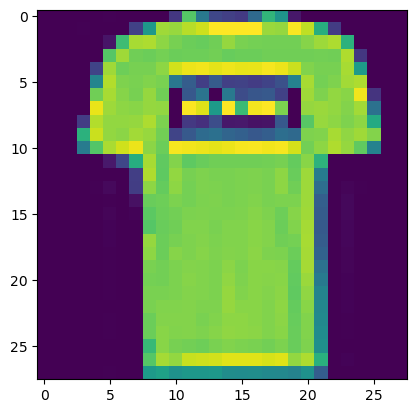

In [6]:
plt.imshow(X_train_full[1])

In [7]:
y_train_full[1]

np.uint8(0)

In [8]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [9]:
class_names[y_train_full[1]]

'T-shirt/top'

In [10]:
X_train_full[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

### Data Normalization
We then normilize the data dimensions so that they're of approx the same scale

In [11]:
X_train_n = X_train_full / 255.0 # Because the pixel values are between 0 and 255, we can divide by 255 to get values between 0 and 1
X_test_n = X_test / 255.0 # Normalize the test set as well

## Test-Train Split
### Split the data into train/validation/test datasets
- Training data - used for training the model
- Validation data - used for tuning the hyperparameters of the model
- Test data - used for evaluating the model after training and tuning

In [12]:
X_valid, X_train = X_train_n[:5000], X_train_n[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test_n

In [13]:
X_valid[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

## Different Ways to create mode ANN in Keras
- Sequential model API
- Functional API
- Subclassing API

In [14]:
np.random.seed(42)
tf.random.set_seed(42)

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

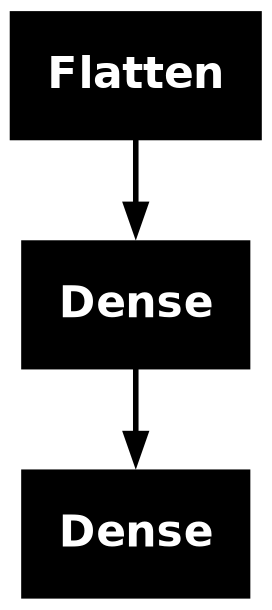

In [17]:
import pydotplus
keras.utils.plot_model(model)

We can access the parameters using the get_weight() method. It returns a list containing the weights and the biases:

In [18]:
weights, biases = model.layers[1].get_weights()

In [19]:
weights

array([[-0.02306675, -0.064648  , -0.08047077, ..., -0.05348572,
         0.03561431,  0.06308764],
       [-0.02346207, -0.02018671, -0.0315726 , ...,  0.03126716,
         0.02203986,  0.01955909],
       [-0.05234836, -0.024049  , -0.03280314, ..., -0.07337743,
        -0.06118834, -0.05353534],
       ...,
       [ 0.08011098,  0.06581698, -0.02163393, ...,  0.02494115,
         0.05928655, -0.0769912 ],
       [ 0.03081194,  0.04440978, -0.00797812, ...,  0.00785023,
         0.01686963,  0.04490428],
       [ 0.05255355,  0.00058442, -0.01452433, ..., -0.03614567,
         0.06467293, -0.06720991]], shape=(784, 100), dtype=float32)

In [20]:
weights.shape

(784, 100)

In [21]:
biases

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

In [22]:
biases.shape

(100,)

In [23]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])

In [24]:
model_history = model.fit(X_train, y_train, epochs=30,
                          validation_data=(X_valid, y_valid))

Epoch 1/30


W0000 00:00:1777122478.546647  110113 cpu_allocator_impl.cc:82] Allocation of 172480000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7571 - loss: 0.7607 - val_accuracy: 0.8252 - val_loss: 0.5518
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8219 - loss: 0.5268 - val_accuracy: 0.8422 - val_loss: 0.4842
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8355 - loss: 0.4793 - val_accuracy: 0.8478 - val_loss: 0.4534
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8443 - loss: 0.4535 - val_accuracy: 0.8542 - val_loss: 0.4342
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8502 - loss: 0.4357 - val_accuracy: 0.8580 - val_loss: 0.4199
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8552 - loss: 0.4215 - val_accuracy: 0.8600 - val_loss: 0.4092
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8582 - loss: 0.4096 - val_accuracy: 0.8624 - val_loss: 0.4003
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8620 - loss: 0.3995 - val_accurac

In [25]:
model_history.params

{'verbose': 'auto', 'epochs': 30, 'steps': 1719}

In [26]:
model_history.history

{'accuracy': [0.7570727467536926,
  0.8219454288482666,
  0.8354727029800415,
  0.8442727327346802,
  0.8502181768417358,
  0.8552181720733643,
  0.8582181930541992,
  0.8620363473892212,
  0.8654545545578003,
  0.8680182099342346,
  0.8699272871017456,
  0.8720727562904358,
  0.8736909031867981,
  0.8754181861877441,
  0.876945436000824,
  0.8784363865852356,
  0.8795636296272278,
  0.8807636499404907,
  0.8821818232536316,
  0.8833454251289368,
  0.8844909071922302,
  0.8858363628387451,
  0.887109100818634,
  0.8881454467773438,
  0.8892727494239807,
  0.8900363445281982,
  0.8911272883415222,
  0.8922363519668579,
  0.8934727311134338,
  0.8943818211555481],
 'loss': [0.7607247233390808,
  0.5267914533615112,
  0.47926968336105347,
  0.45350462198257446,
  0.43565499782562256,
  0.4214961528778076,
  0.4096459746360779,
  0.39952030777931213,
  0.39071428775787354,
  0.3830239474773407,
  0.37602055072784424,
  0.36969056725502014,
  0.3638225793838501,
  0.358357697725296,
  0.353

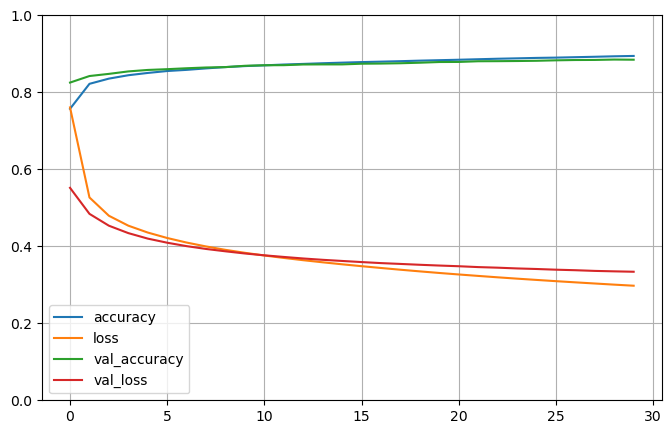

In [27]:
import pandas as pd

pd.DataFrame(model_history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [28]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8710 - loss: 0.3631


[0.3630862534046173, 0.8709999918937683]

In [29]:
X_new = X_test[:3]

In [30]:
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[0.  , 0.  , 0.  , 0.  , 0.  , 0.07, 0.  , 0.06, 0.  , 0.86],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ]],
      dtype=float32)

In [31]:
y_pred = np.argmax(model.predict(X_new), axis=1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


array([9, 2, 1])

In [32]:
np.array(class_names)[y_pred]

array(['Ankle boot', 'Pullover', 'Trouser'], dtype='<U11')

AxesImage(shape=(28, 28))


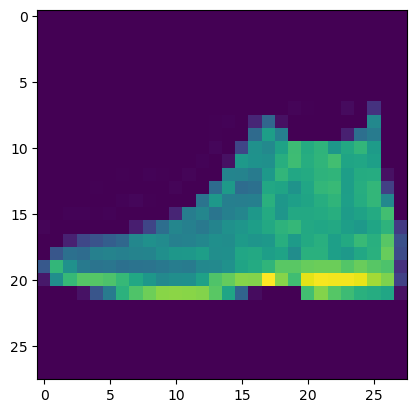

In [33]:
print(plt.imshow(X_test[0]))

AxesImage(shape=(28, 28))


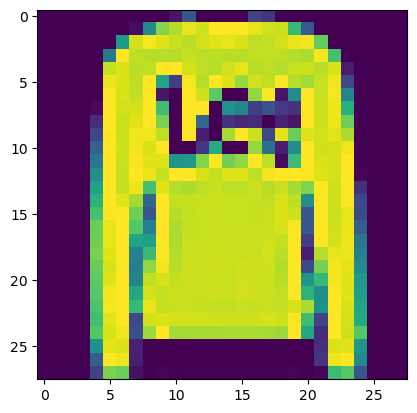

In [34]:
print(plt.imshow(X_test[1]))

AxesImage(shape=(28, 28))


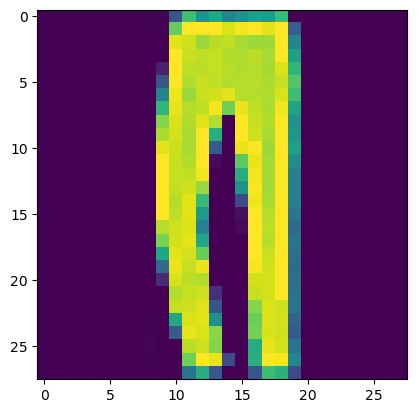

In [35]:
print(plt.imshow(X_test[2]))